# Visualizzazione distribuzione personaggi

In [ ]:
#!pip install matplotlib
#!pip install seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_prepare_data(csv_path):
    # Caricamento file
    df = pd.read_csv(csv_path)

    # Manteniamo solo le colonne necessarie
    df = df[['title', 'author_gender', 'Gender', 'type']]

    # Estrazione anno (prime 4 cifre del titolo)
    df['year'] = df['title'].str.extract(r'^(\d{4})').astype(int)

    # 🔹 FILTRO IMPORTANTE: manteniamo solo type 0 e 1
    df = df[df['type'].isin([0, 1])]

    return df


def create_time_bins(df, bin_size=5):
    bins = list(range(1833, 1943, bin_size))
    labels = [f"{b}-{b+bin_size-1}" for b in bins[:-1]]

    df['period'] = pd.cut(df['year'], bins=bins, labels=labels, right=False)

    return df


def aggregate_data(df):
    grouped = (
        df
        .groupby(['period', 'author_gender', 'Gender', 'type'])
        .size()
        .reset_index(name='count')
    )
    return grouped


def plot_evolution(grouped_df):
    sns.set(style="whitegrid")
    plt.figure(figsize=(14, 8))

    # Creiamo etichette leggibili
    grouped_df['author_label'] = grouped_df['author_gender'].map({0: "Author M", 1: "Author F"})
    grouped_df['char_gender_label'] = grouped_df['Gender'].map({0: "Char M", 1: "Char F"})
    grouped_df['type_label'] = grouped_df['type'].map({0: "Adult", 1: "Child"})

    grouped_df['category'] = (
        grouped_df['author_label'] + " | " +
        grouped_df['char_gender_label'] + " | " +
        grouped_df['type_label']
    )

    sns.lineplot(
        data=grouped_df,
        x='period',
        y='count',
        hue='category',
        marker="o"
    )

    plt.xticks(rotation=45)
    plt.title("Evolution of characters (1833–1941)")
    plt.xlabel("Period")
    plt.ylabel("Number of characters")
    plt.tight_layout()
    plt.show()


def main(csv_path, bin_size=5):
    df = load_and_prepare_data(csv_path)
    df = create_time_bins(df, bin_size=bin_size)
    grouped = aggregate_data(df)
    plot_evolution(grouped)

/var/folders/hh/ypps8hc950qcwq52q102337r0000gn/T/ipykernel_22473/3281280582.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['period', 'author_gender', 'Gender', 'type'])


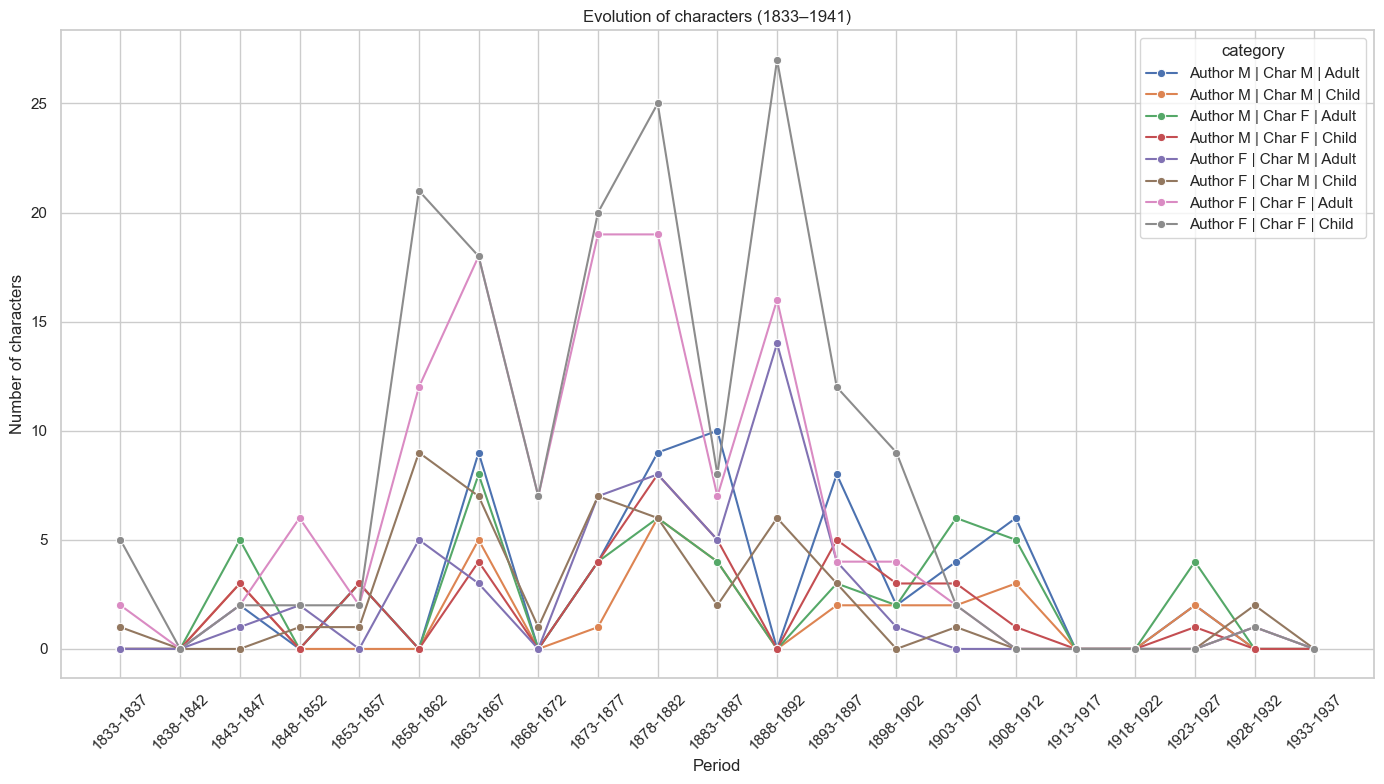

In [ ]:
main("Metadata/5_char_for_novel.csv", bin_size=5)
# main("tuo_file.csv", bin_size=10)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_prepare_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df[['title', 'author_gender', 'Gender', 'type']]

    # Estrazione anno
    df['year'] = df['title'].str.extract(r'^(\d{4})').astype(int)

    # Manteniamo solo type 0 e 1
    df = df[df['type'].isin([0, 1])]

    return df


def create_time_bins(df, bin_size=5):
    bins = list(range(1833, 1943, bin_size))
    df['period_start'] = (df['year'] - 1833) // bin_size * bin_size + 1833
    return df


def aggregate_data(df):
    grouped = (
        df
        .groupby(['period_start', 'author_gender', 'Gender', 'type'])
        .size()
        .reset_index(name='count')
    )
    return grouped


def plot_trend(grouped_df):
    sns.set(style="whitegrid")

    # Etichette leggibili
    grouped_df['char_gender_label'] = grouped_df['Gender'].map({0: "Pers M", 1: "Pers F"})
    grouped_df['type_label'] = grouped_df['type'].map({0: "Adulto", 1: "Bambino"})
    grouped_df['category'] = (
        grouped_df['char_gender_label'] + " | " +
        grouped_df['type_label']
    )

    # Due subplot: autore M e autore F
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for author_gender, ax in zip([0, 1], axes):
        subset = grouped_df[grouped_df['author_gender'] == author_gender]

        for cat in subset['category'].unique():
            cat_data = subset[subset['category'] == cat]

            sns.regplot(
                data=cat_data,
                x='period_start',
                y='count',
                scatter=False,      # niente punti
                ci=None,            # niente intervallo di confidenza
                ax=ax,
                label=cat
            )

        ax.set_title(f"Author {'M' if author_gender == 0 else 'F'}")
        ax.set_xlabel("Year (period beginning)")
        ax.set_ylabel("Number of characters")
        ax.legend()

    plt.suptitle("Historical trend of the characters (1833–1941)")
    plt.tight_layout()
    plt.show()


def main(csv_path, bin_size=5):
    df = load_and_prepare_data(csv_path)
    df = create_time_bins(df, bin_size=bin_size)
    grouped = aggregate_data(df)
    plot_trend(grouped)

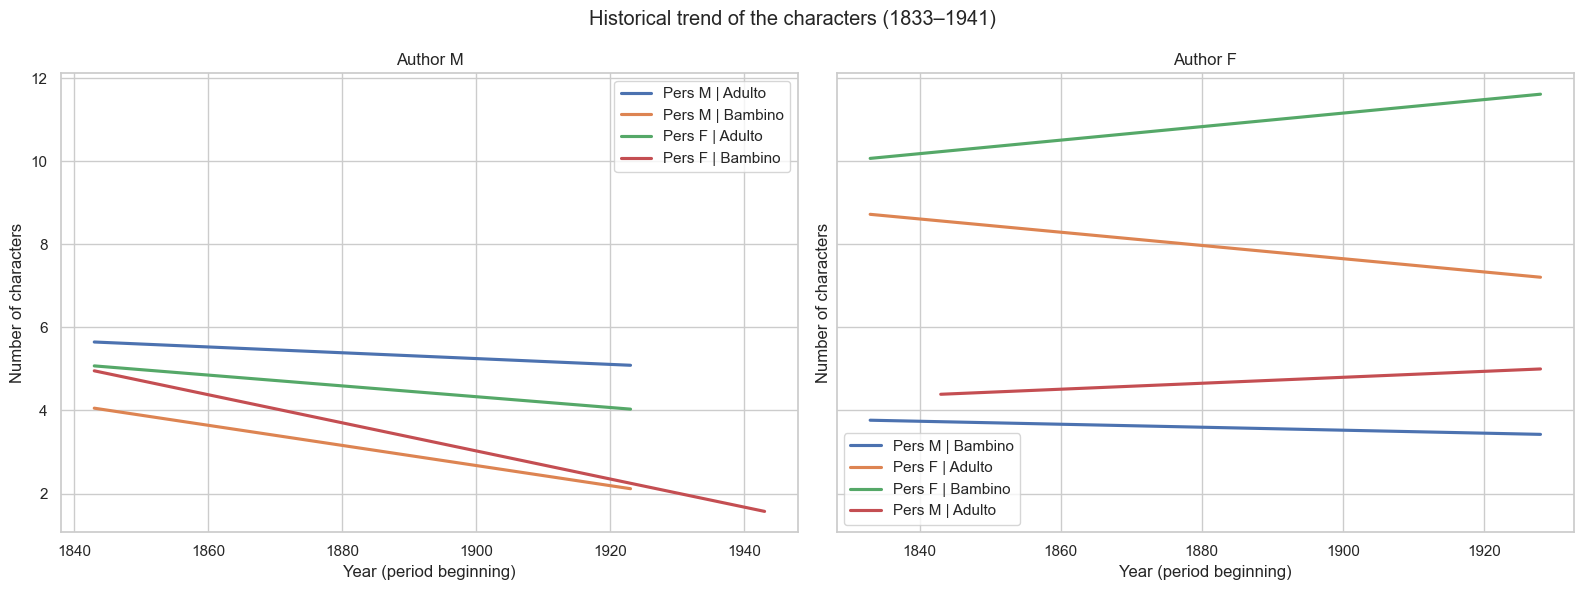

In [ ]:
# Esempio:
main("/Metadata/5_char_for_novel.csv", bin_size=5)
# main("tuo_file.csv", bin_size=10)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def load_and_prepare_data(csv_path):
    df = pd.read_csv(csv_path)
    df = df[['title', 'author_gender', 'Gender', 'type']]

    # Estrazione anno
    df['year'] = df['title'].str.extract(r'^(\d{4})').astype(int)

    # Manteniamo solo type 0 e 1
    df = df[df['type'].isin([0, 1])]

    return df


def create_time_bins(df, bin_size=5):
    df['period_start'] = (df['year'] - 1833) // bin_size * bin_size + 1833
    return df


def aggregate_for_area(df):
    # Creiamo etichette leggibili
    df['char_gender_label'] = df['Gender'].map({0: "Male", 1: "Female"})
    df['type_label'] = df['type'].map({0: "Adult", 1: "Child"})
    df['category'] = df['char_gender_label'] + " | " + df['type_label']

    grouped = (
        df
        .groupby(['period_start', 'author_gender', 'category'])
        .size()
        .reset_index(name='count')
    )

    return grouped


def plot_stacked_area(grouped_df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for author_gender, ax in zip([0, 1], axes):

        subset = grouped_df[grouped_df['author_gender'] == author_gender]

        # Pivot per area plot
        pivot = subset.pivot(
            index='period_start',
            columns='category',
            values='count'
        ).fillna(0)

        pivot = pivot.sort_index()

        ax.stackplot(
            pivot.index,
            pivot.T,
            labels=pivot.columns
        )

        ax.set_title(f"{'Male' if author_gender == 0 else 'Female'} Author")
        ax.set_xlabel("Publication year")
        ax.set_ylabel("Number of characters (top 5 for each novel)")
        ax.legend(loc='upper left')

    plt.suptitle("Characters compositions in time (1833–1941)")
    plt.tight_layout()
    plt.show()


def main(csv_path, bin_size=5):
    df = load_and_prepare_data(csv_path)
    df = create_time_bins(df, bin_size)
    grouped = aggregate_for_area(df)
    plot_stacked_area(grouped)


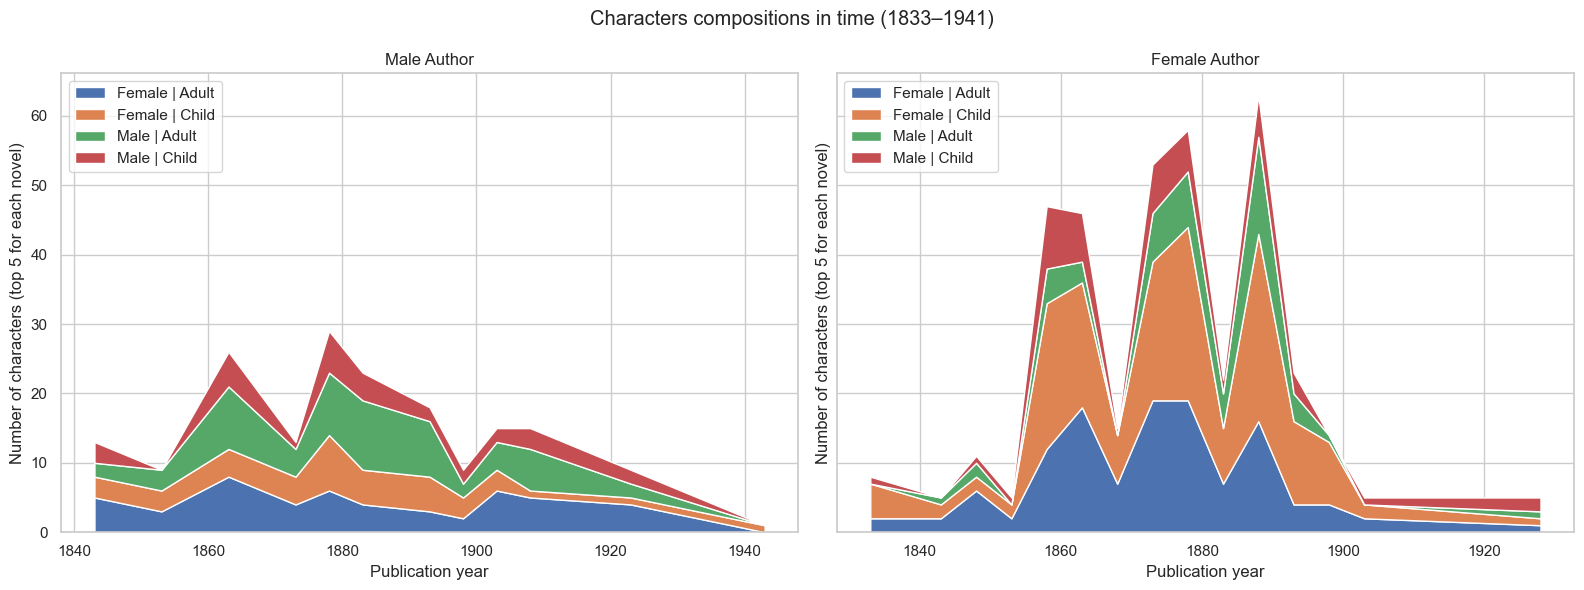

In [ ]:
# Esempio:
main("Metadata/5_char_for_novel.csv", bin_size=5)
# main("tuo_file.csv", bin_size=10)